In [ ]:
import pandas as pd
from pathlib import Path
from fastai import *
from fastai.vision.all import *
import torch

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda:0
GPU: NVIDIA GeForce RTX 4070


In [10]:
data_folder = Path("./aerial-cactus-identification/data/aerial-cactus-identification")

train_df = pd.read_csv(data_folder / "train.csv")
test_df = pd.read_csv(data_folder / "sample_submission.csv")

train_path = data_folder / "train"
test_path = data_folder / "test"

In [11]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=lambda row: train_path / row["id"],
    get_y=ColReader("has_cactus"),
    splitter=RandomSplitter(valid_pct=0.01, seed=42),
    item_tfms=Resize(128),
    batch_tfms=[
        *aug_transforms(
            do_flip=True,
            flip_vert=True,
            max_rotate=10.0,
            max_zoom=1.1,
            max_lighting=0.2,
            max_warp=0.2,
            p_affine=0.75,
            p_lighting=0.75
        ),
        Normalize.from_stats(*imagenet_stats)
    ]
)

dls = dblock.dataloaders(
    train_df,
    bs=64,
    device=device
)

In [16]:
learn = vision_learner(
    dls,
    densenet161,
    metrics=[error_rate, accuracy]
)

learn.fine_tune(5, base_lr=3e-2)

test_files = [test_path / fname for fname in test_df["id"]]
test_dl = dls.test_dl(test_files)

preds, _ = learn.get_preds(dl=test_dl)

submission = pd.DataFrame({
    "id": test_df["id"],
    "has_cactus": preds[:, 1].cpu().numpy()
})

submission.to_csv("predictions.csv", index=False)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.090170,0.037534,0.007092,0.992908,01:20


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.051658,0.040865,0.007092,0.992908,01:43
1,0.077247,0.001192,0.000000,1.000000,01:46
2,0.025871,0.000301,0.000000,1.000000,01:48
3,0.010492,0.000102,0.000000,1.000000,01:47
4,0.004384,0.000108,0.000000,1.000000,01:45


In [17]:
check = pd.read_csv("predictions.csv")

print(check.shape)
print(check.columns.tolist())
print(check.isna().sum())
print(check.head())

(3325, 2)
['id', 'has_cactus']
id            0
has_cactus    0
dtype: int64
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.999987
1  134f04305c795d6d202502c2ce3578f3.jpg    1.000000
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999992
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.999999
4  b77dc902b035887cbbc01920ce0e3151.jpg    1.000000


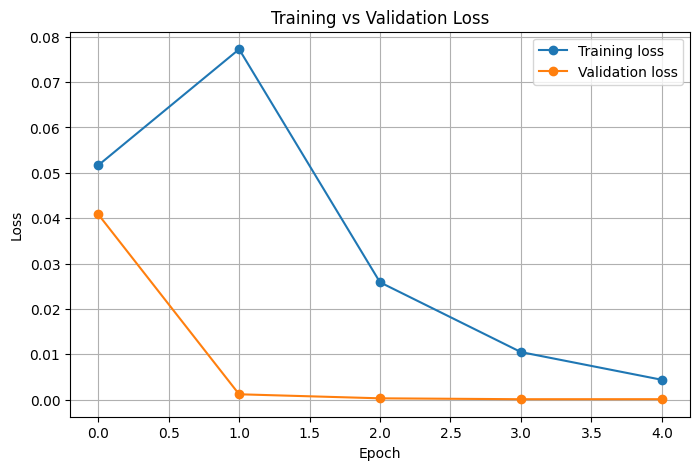

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

history = pd.DataFrame({
    "epoch": [0, 1, 2, 3, 4],
    "train_loss": [0.051658, 0.077247, 0.025871, 0.010492, 0.004384],
    "valid_loss": [0.040865, 0.001192, 0.000301, 0.000102, 0.000108]
})

plt.figure(figsize=(8, 5))

plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training loss")
plt.plot(history["epoch"], history["valid_loss"], marker="o", label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()